In [1]:
import torch
import numpy as np
from copy import deepcopy
import pickle as pkl

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from utils_plot import *
from tqdm import tqdm
from utils import *
from functools import reduce
import os
from joblib import Parallel, delayed
import shutil


In [2]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [41]:
C = Config()

C.G = 0.8
C.linear_net = False
C.learning_rate = 0.001
C.L=10
C.print_progress = True
C.length_corridors = [30]*1
C.max_move = C.length_corridors[0]//2
C.hidden_size = 250 # len(C.length_corridors) * (C.length_corridors[0] * 3 - 1)
C.num_epochs = 10000
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.bias = False
C.split_actions = False
C.cyclic_corridors = True

# var_name = 'G'
# var_values = [0.1, 1, 10]
var_name = 'max_move'
var_values =  np.arange(C.length_corridors[0]) #  [1, C.length_corridors[0]//4, C.length_corridors[0]//2, 3*C.length_corridors[0]//4, C.length_corridors[0]-1] # np.arange(C.length_corridors[0]) #  
# var_name = 'L'
# var_values = np.arange(8)
# var_values = np.arange(6, 16)

In [42]:


# Ensure the results directory exists
results_dir = f'results/notebook_results/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    if var_name == 'L':
        C_local.learning_rate = C.learning_rate * 0.5**C_local.L
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value) for var_value in var_values
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

Number of samples: 90
Input dimension: 33
Output dimension: 30
Number of actions: 3

Sig_2 of last hidden: 1.0794347105047564e-07


  0%|          | 0/10000 [00:00<?, ?it/s]

Number of samples: 210
Input dimension: 37
Output dimension: 30
Number of actions: 7

Sig_2 of last hidden: 1.1885011019785452e-07


  0%|          | 5/10000 [00:00<11:34, 14.38it/s]] 

Number of samples: 30
Input dimension: 31
Output dimension: 30
Number of actions: 1

Sig_2 of last hidden: 6.568728849742911e-08


...

Number of samples: 1290
Input dimension: 73
Output dimension: 30
Number of actions: 43

Sig_2 of last hidden: 1.4992019714554772e-07
Number of samples: 690
Input dimension: 53
Output dimension: 30
Number of actions: 23

Sig_2 of last hidden: 1.4114637281181786e-07
Number of samples: 1110
Input dimension: 67
Output dimension: 30
Number of actions: 37

Sig_2 of last hidden: 1.1069606387081876e-07


  0%|          | 1/10000 [00:01<3:28:54,  1.25s/it]

Number of samples: 1710
Input dimension: 87
Output dimension: 30
Number of actions: 57

Sig_2 of last hidden: 1.2547631911274948e-07
Number of samples: 1410
Input dimension: 77
Output dimension: 30
Number of actions: 47

Sig_2 of last hidden: 1.8974071736010956e-07


 31%|███▏      | 3131/10000 [29:48<1:05:23,  1.75it/s]

 24%|██▍       | 2402/10000 [29:49<1:34:19,  1.34it/s]


KeyboardInterrupt: 

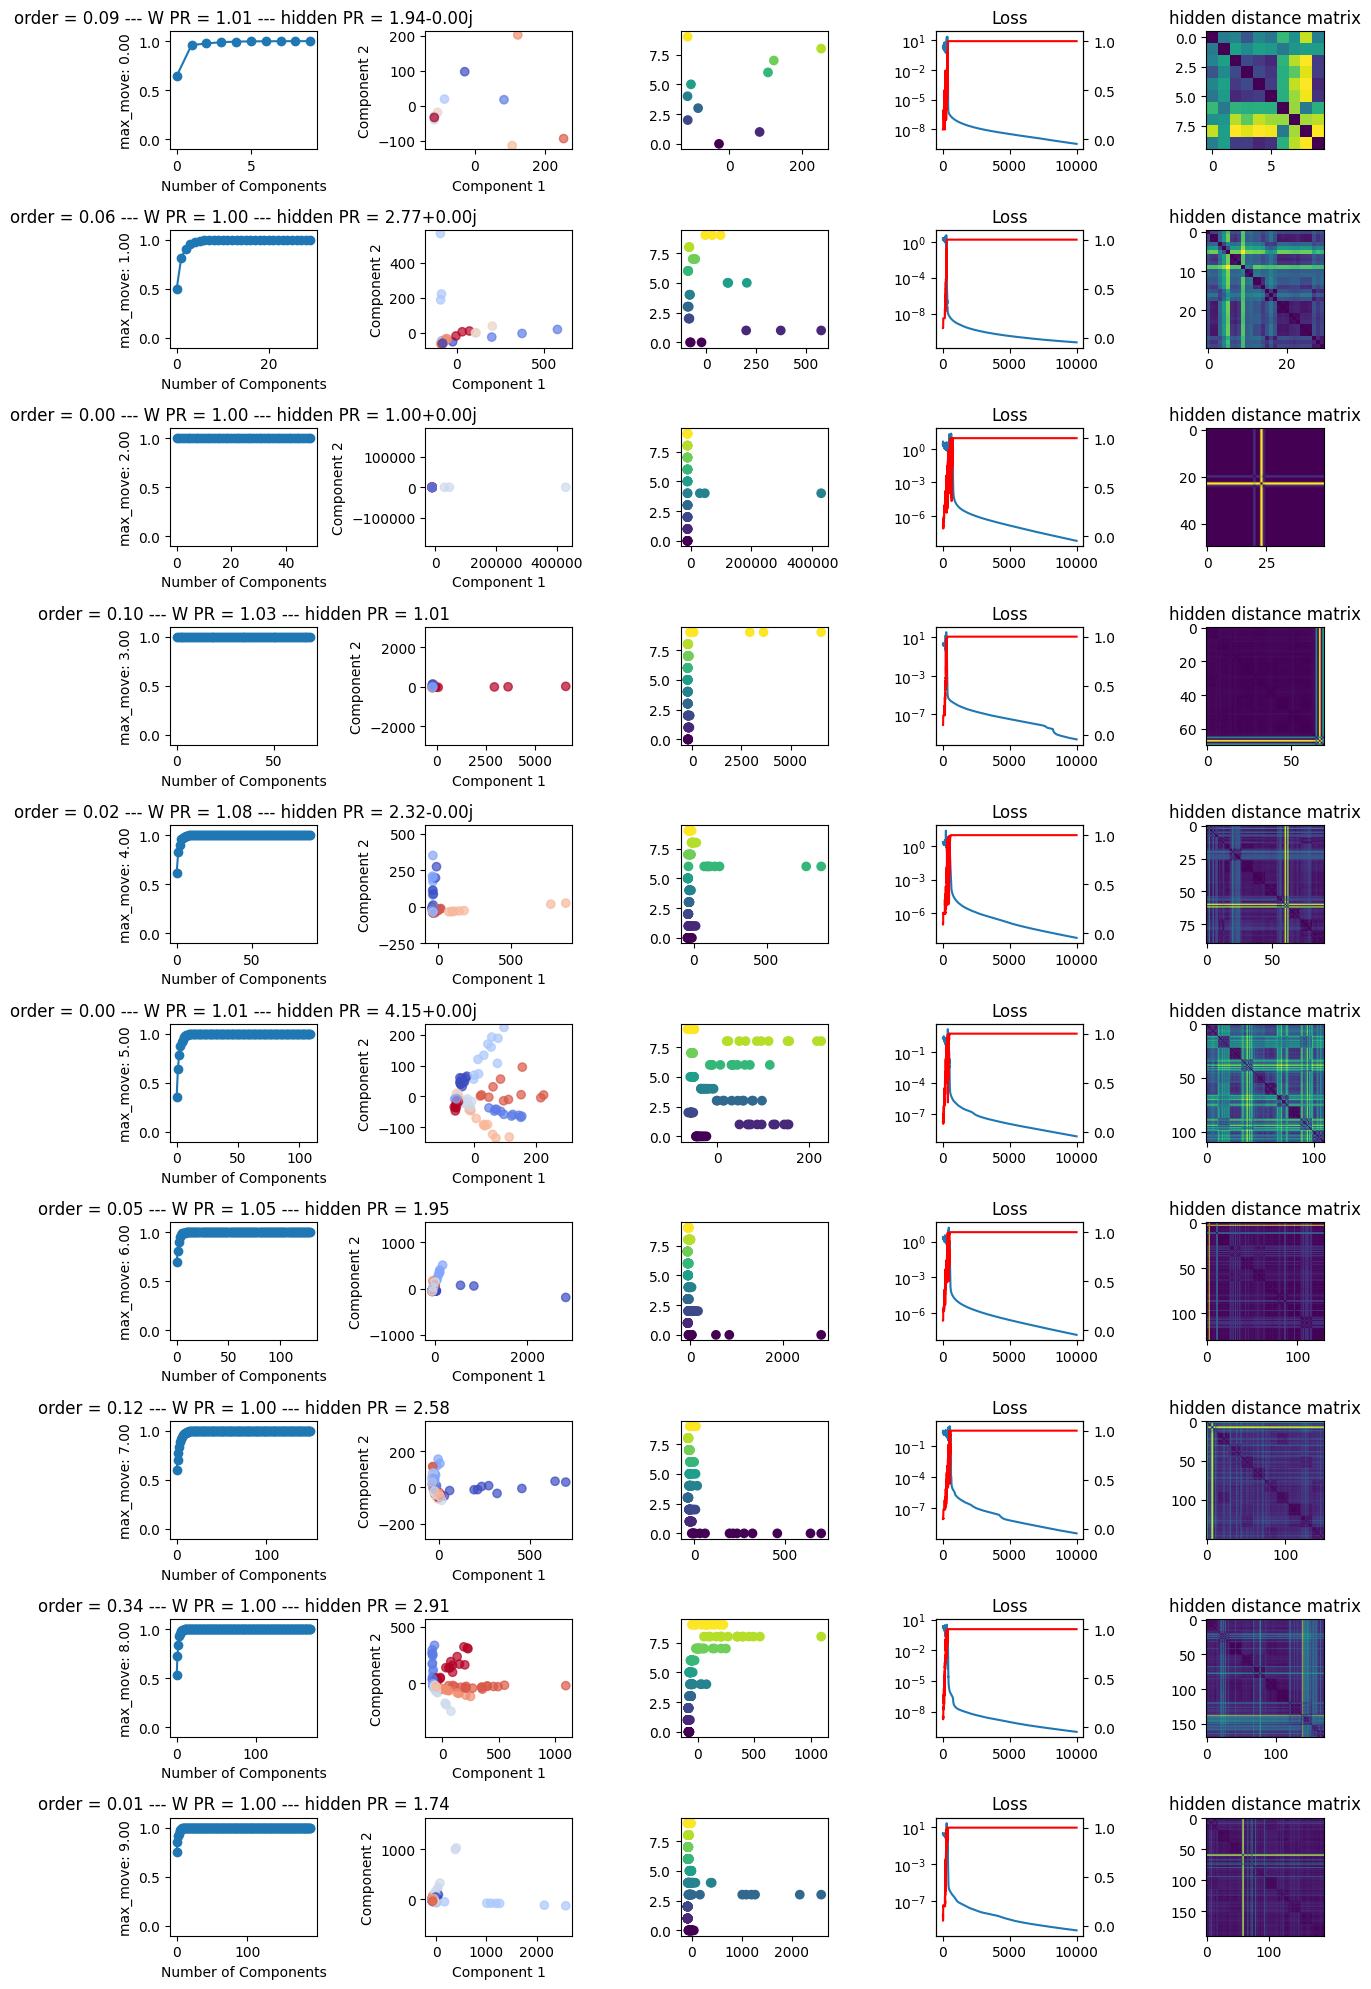

In [ ]:
fig, axs = plt.subplots(len(data_dict_l), 5, figsize=(25/2, len(data_dict_l)*4/2))
for data_dict, axs_current in zip(data_dict_l, axs):
    plot_pca(data_dict, axs=axs_current)
    axs_current[0].set_ylabel(f'{var_name}: {getattr(data_dict["C"], var_name):.2f}')

In [ ]:
import numpy as np

def circular_label_r2(points, labels, L):
    """
    Compute an R²-like metric for how well a set of 2D points fits a circle
    AND how well their labels match the circular ordering.
    
    Parameters
    ----------
    points : np.ndarray
        Shape (N, 2). Each row is a point (x, y).
    labels : np.ndarray
        Shape (N,). Integer labels in range [0, L-1].
    L : int
        Total number of unique labels.

    Returns
    -------
    R2 : float
        Combined R²-like metric (0 to 1, may be negative if no structure).
    center : tuple
        (xc, yc) fitted circle center.
    radius : float
        Fitted circle radius.
    best_offset : float
        Best rotation offset (in radians) between labels and positions.
    """
    x, y = points[:, 0], points[:, 1]
    
    # --- Step 1: Fit circle to points ---
    A = np.column_stack([2*x, 2*y, np.ones_like(x)])
    b = x**2 + y**2
    sol, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    xc, yc, c = sol
    radius = np.sqrt(c + xc**2 + yc**2)
    
    # --- Step 2: Compute angles of points ---
    theta = np.arctan2(y - yc, x - xc)
    theta = np.mod(theta, 2*np.pi)

    # --- Step 3: Map labels to expected angles ---
    phi = (2 * np.pi / L) * labels

    # --- Step 4: Find best rotation offset analytically ---
    # Equivalent to aligning two circular signals using complex numbers
    complex_diff = np.exp(1j * theta) * np.conj(np.exp(1j * phi))
    best_offset = np.angle(np.mean(complex_diff))

    # --- Step 5: Compute minimal cyclic residuals ---
    delta = (theta - (phi + best_offset) + np.pi) % (2*np.pi) - np.pi

    # --- Step 6: Compute R²-like metric ---
    ss_res = np.sum(delta**2)
    
    # Total variance of theta relative to its circular mean
    mean_angle = np.angle(np.mean(np.exp(1j * theta)))
    theta_centered = (theta - mean_angle + np.pi) % (2*np.pi) - np.pi
    ss_tot = np.sum(theta_centered**2)

    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
    
    return R2


In [ ]:
def calc_metrics(data_dict, i=-1):
    hidden = data_dict['hidden_states'][i].cpu().detach().numpy()
    PR = calc_PR(hidden)
    loc_y = data_dict['loc_y']
    loc_X = data_dict['loc_X']
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    order = np.mean([get_r_2(PCA(n_components=1).fit_transform(hidden[corridor==cor]), loc_y[corridor==cor]) for cor in np.unique(corridor)])
    NC1 = circular_label_r2(PCA(n_components=2).fit_transform(hidden), loc_X, data_dict['C'].length_corridors[0])
    return PR, order, NC1

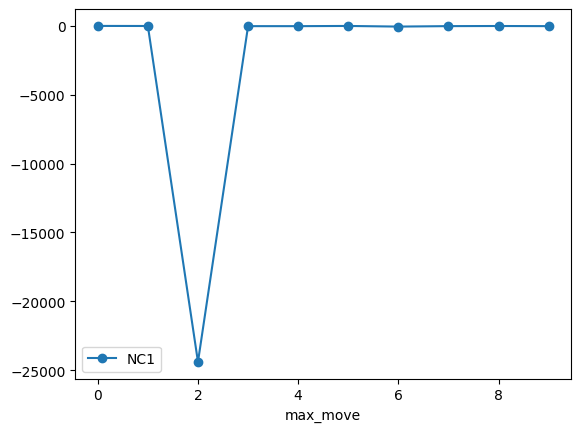

In [ ]:

PR_l = []
order_l = []
NC_l = []
for data_dict in data_dict_l:
    PR, order, NC = calc_metrics(data_dict)
    PR_l.append(1/PR)
    order_l.append(order)
    NC_l.append(NC)
# plt.plot(var_values, order_l, label='order', marker='o')   
plt.plot(var_values, NC_l, label='NC1', marker='o')
# plt.plot(var_values, PR_l, label='1/PR', marker='o', c='tab:green')
plt.legend()
plt.xlabel(var_name)
# plt.ylim(0)
# plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.show()

X shape: (10, 11) --- U shape: (10, 10) --- V shape: (10, 11)
X shape: (30, 13) --- U shape: (10, 10) --- V shape: (10, 13)
X shape: (50, 15) --- U shape: (10, 10) --- V shape: (10, 15)
X shape: (70, 17) --- U shape: (10, 10) --- V shape: (10, 17)
X shape: (90, 19) --- U shape: (10, 10) --- V shape: (10, 19)
X shape: (110, 21) --- U shape: (10, 10) --- V shape: (10, 21)
X shape: (130, 23) --- U shape: (10, 10) --- V shape: (10, 23)
X shape: (150, 25) --- U shape: (10, 10) --- V shape: (10, 25)
X shape: (170, 27) --- U shape: (10, 10) --- V shape: (10, 27)
X shape: (190, 29) --- U shape: (10, 10) --- V shape: (10, 29)


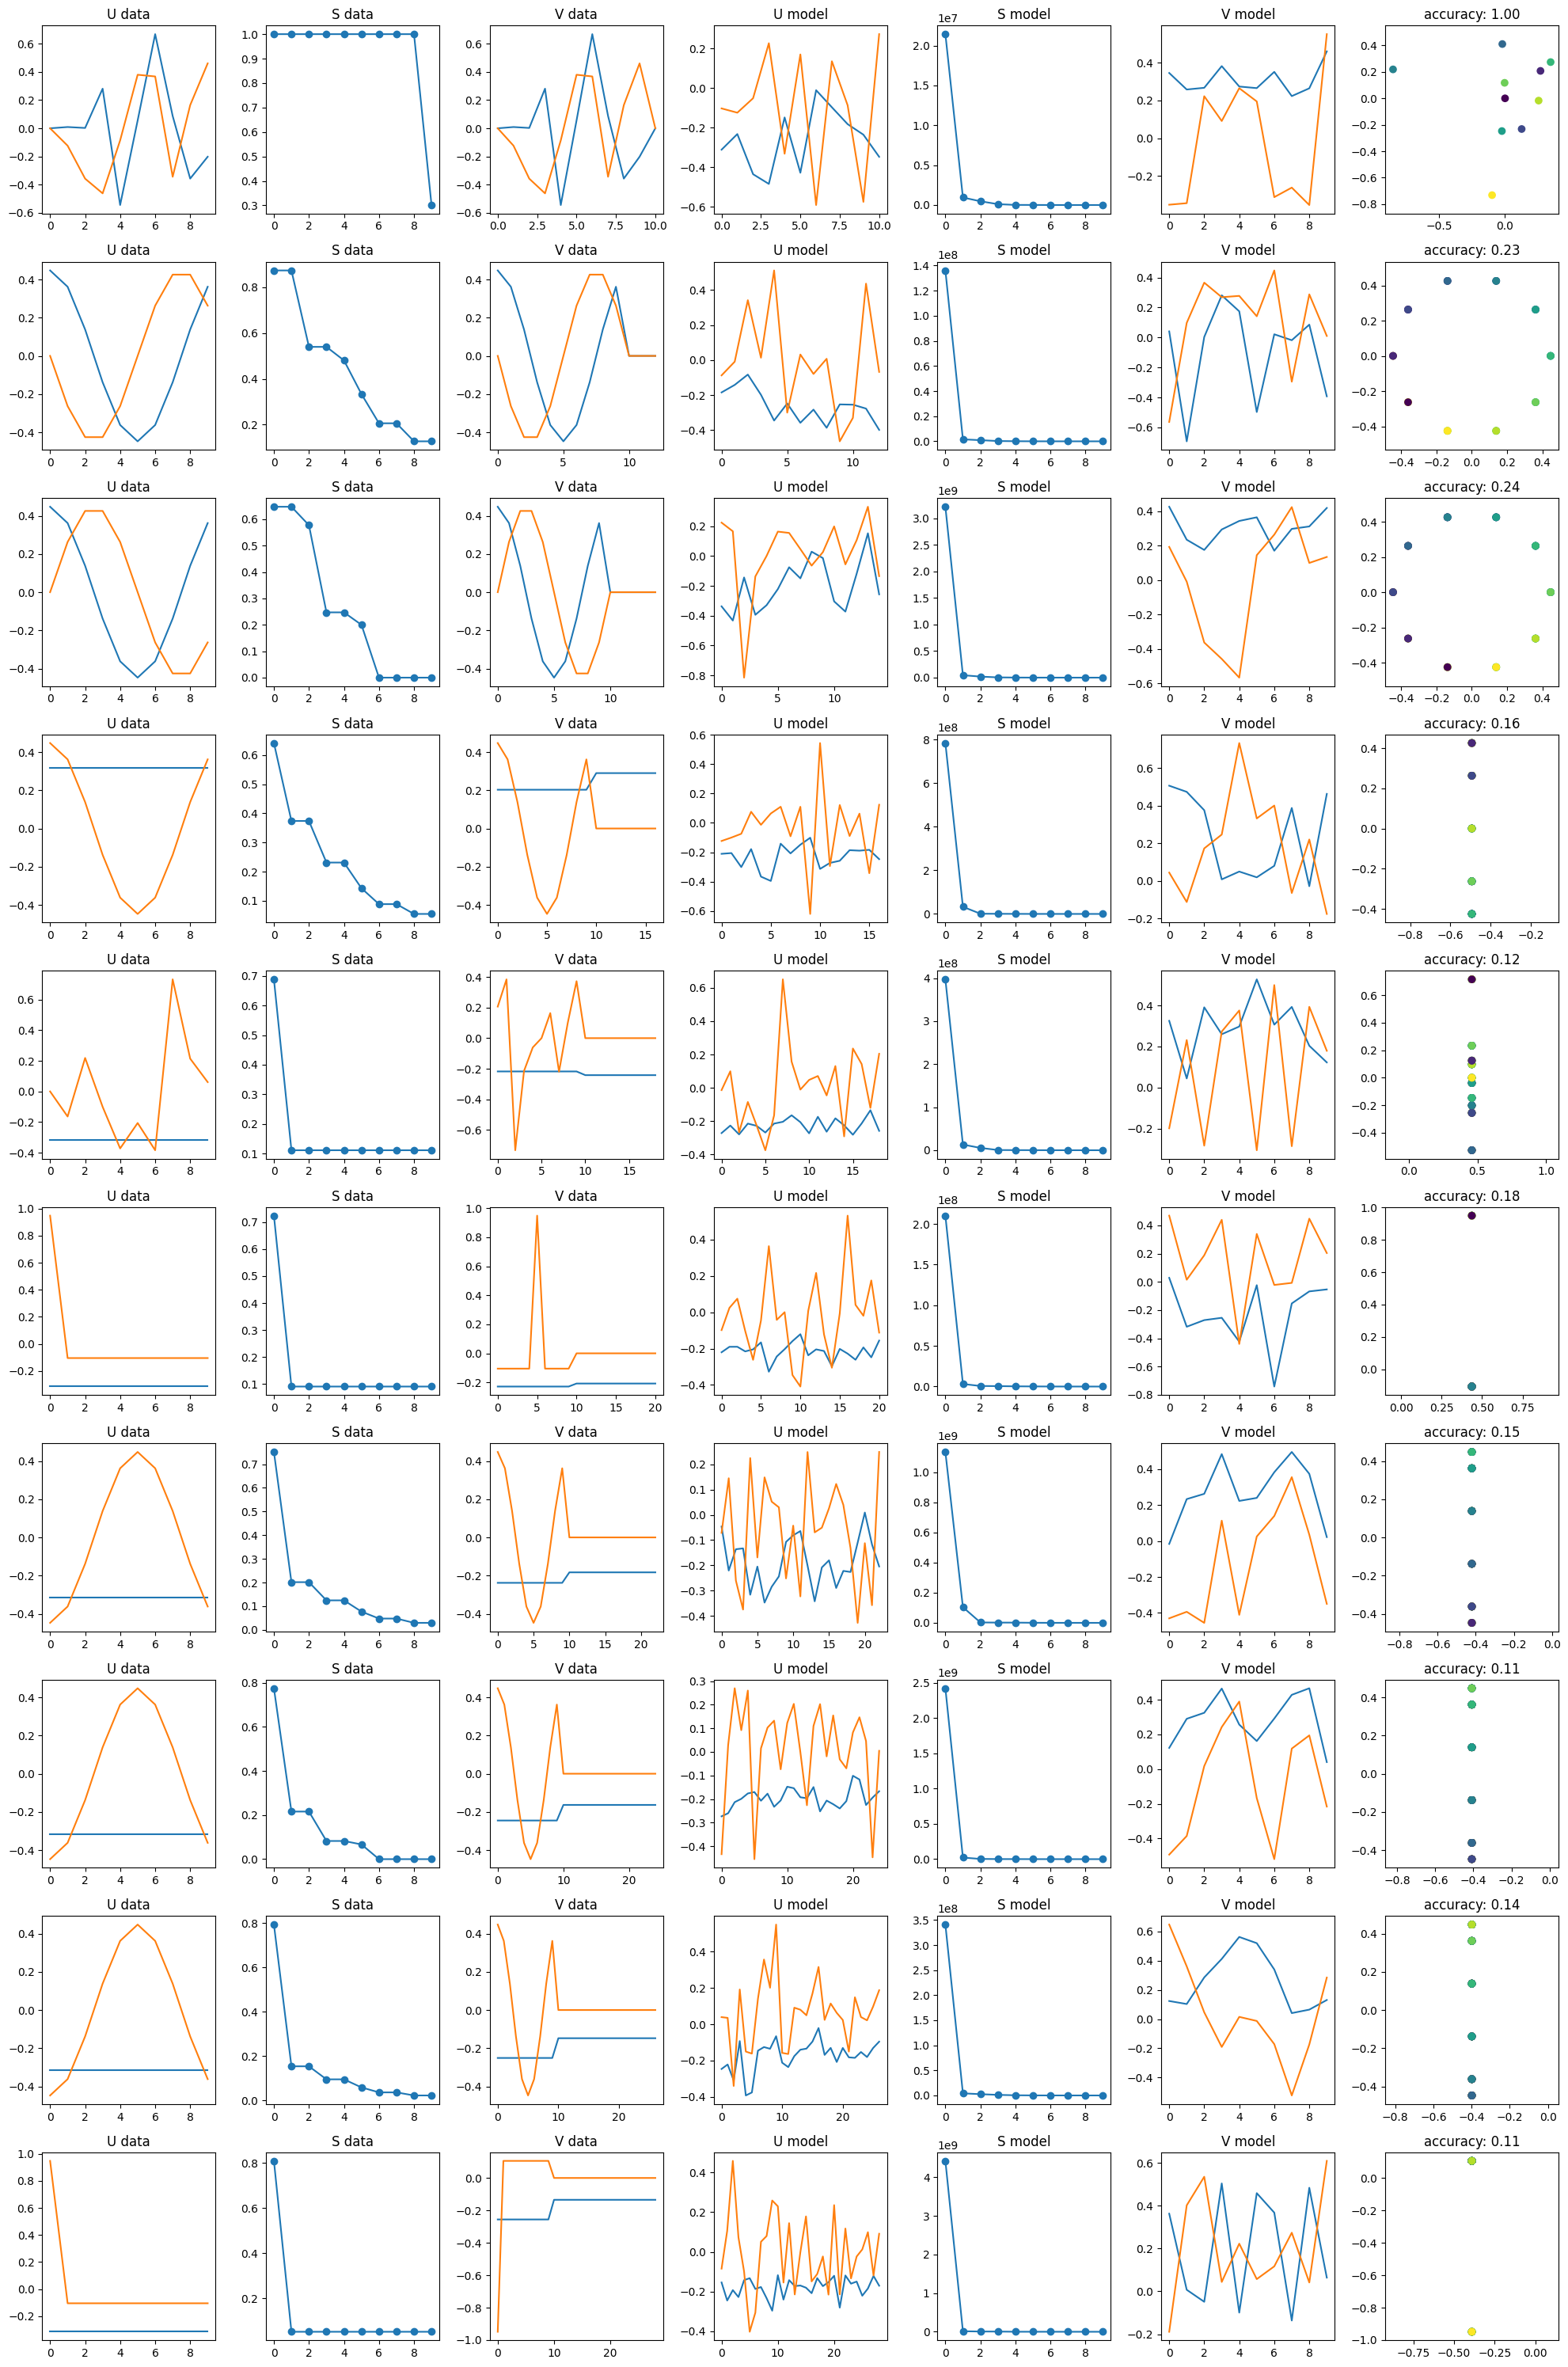

In [ ]:
fig, axs_all = plt.subplots(len(data_dict_l), 7, figsize=(20, 3*len(data_dict_l)))
for data_dict, axs in zip(data_dict_l, axs_all):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(y.T@X, dtype=np.float64)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    U, S, V = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    print(f'X shape: {X.shape} --- U shape: {U.shape} --- V shape: {V.shape}')

    rank = 2
    axs[0].plot(U[:, :rank])
    axs[0].set_title('U data')
    axs[1].plot(S, marker='o')
    axs[1].set_title('S data')
    axs[2].plot(V[:rank].T)
    axs[2].set_title('V data')

    U, S, V = np.linalg.svd(W, full_matrices=False)
    axs[3].plot(U[:, :rank])
    axs[3].set_title('U model')
    axs[4].plot(S, marker='o')
    axs[4].set_title('S model')
    axs[5].plot(V[:rank].T)
    axs[5].set_title('V model')
    plt.tight_layout()
    

    W_corr = Sigma31@np.linalg.pinv(Sigma11)
    U, S, V = np.linalg.svd(W_corr.T, full_matrices=False)
    for cor, marker in zip(np.unique(corridor), markers):
        axs[-1].scatter(X[corridor==cor]@U[:, 0], X[corridor==cor]@U[:, 1], c=y[corridor==cor].argmax(1), marker=marker)
    axs[-1].set_title(f'accuracy: {calc_accuracy_from_W(W_corr.T, X, y):.2f}')
    axs[-1].axis('equal')
plt.show()

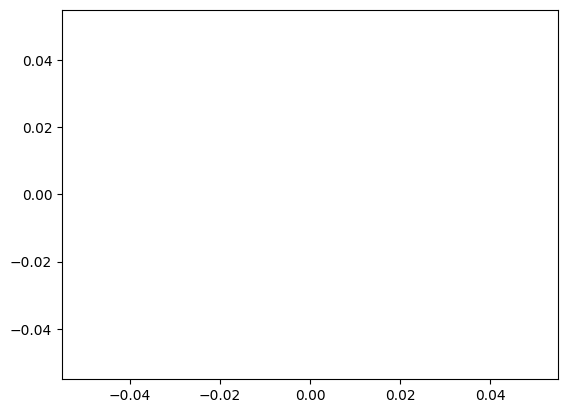

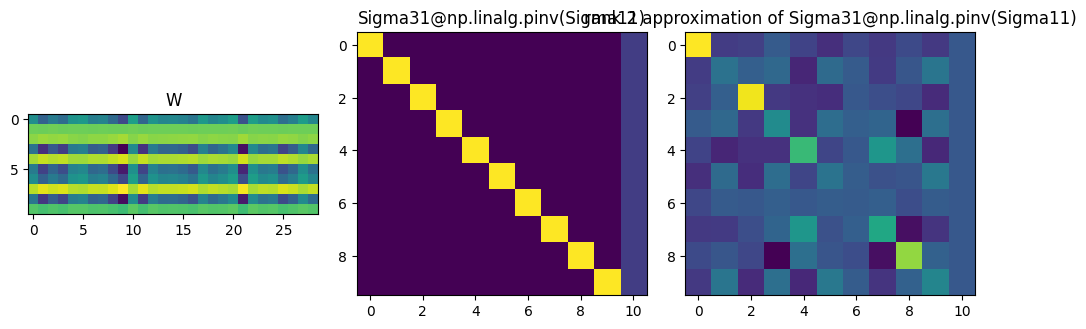

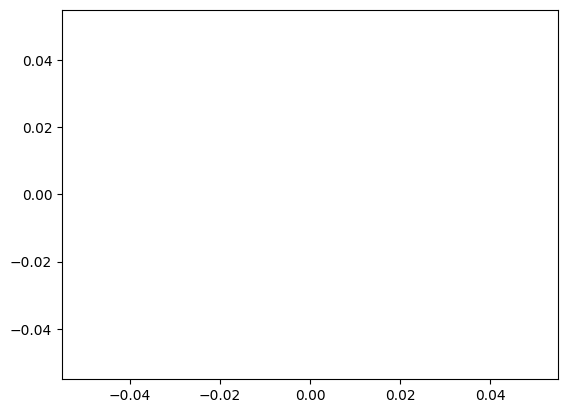

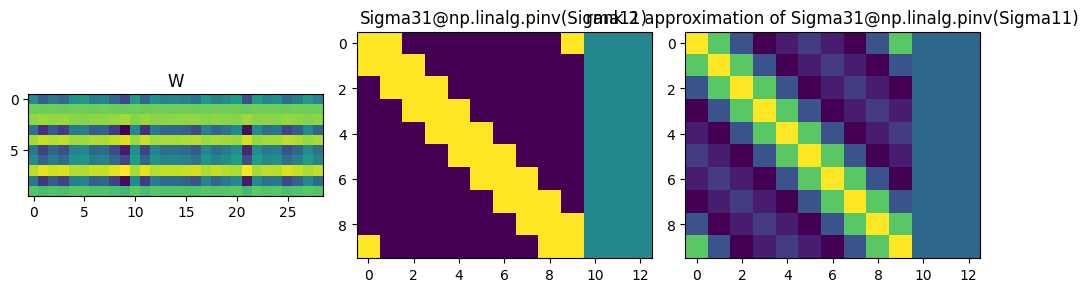

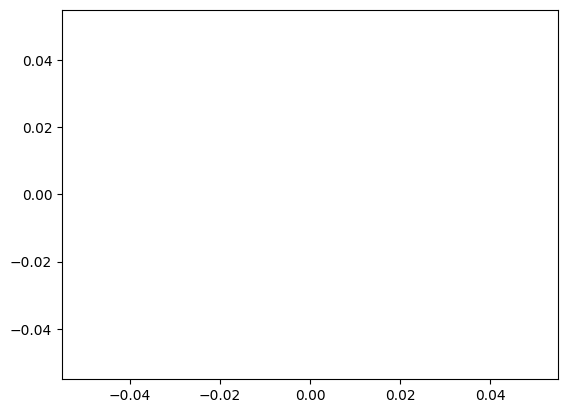

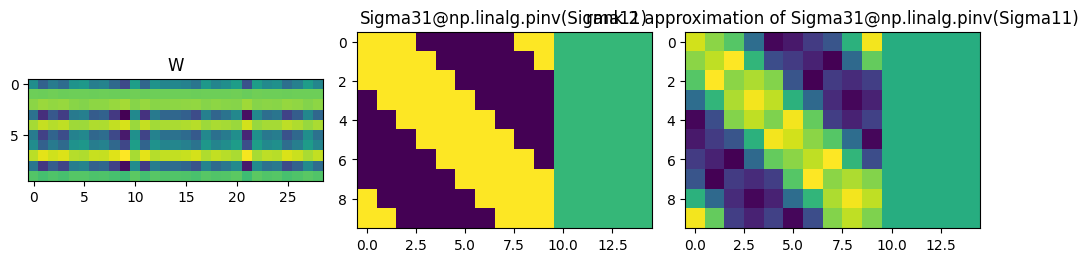

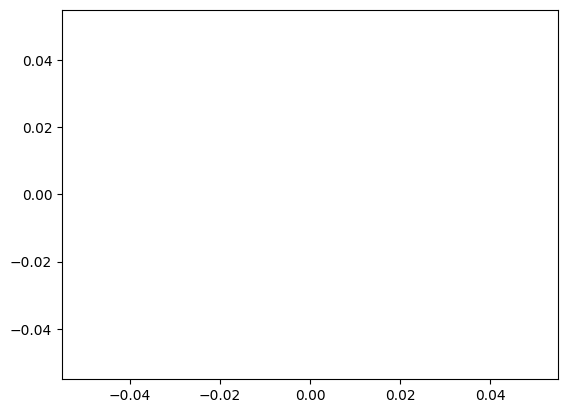

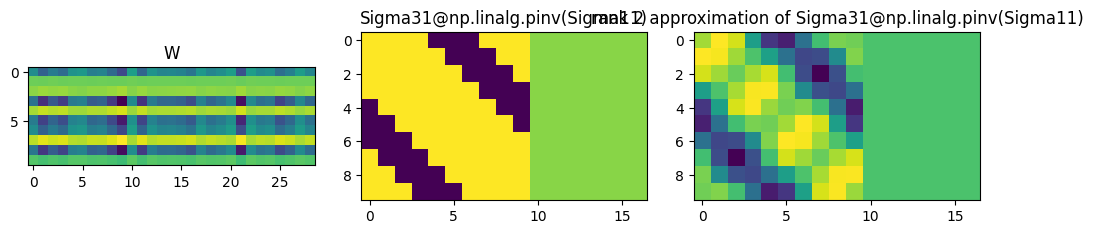

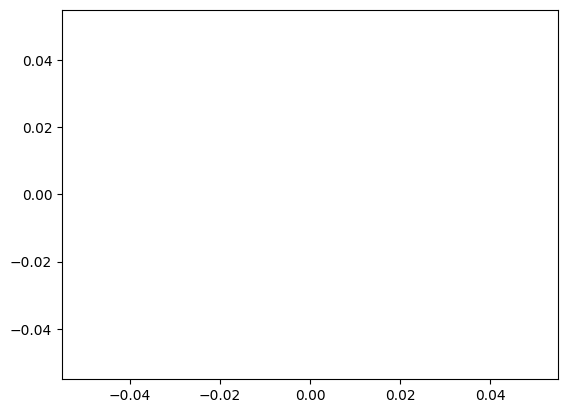

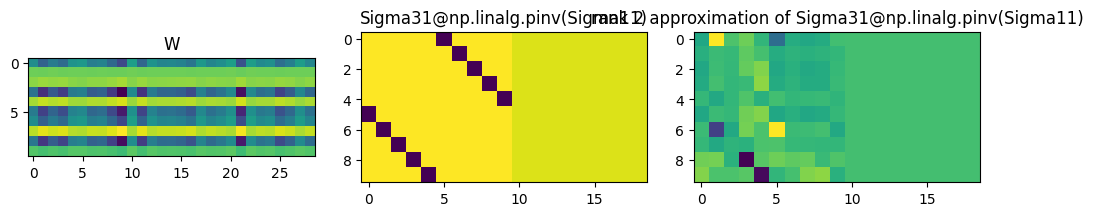

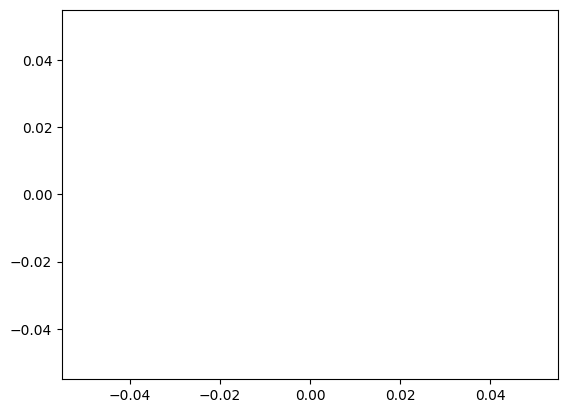

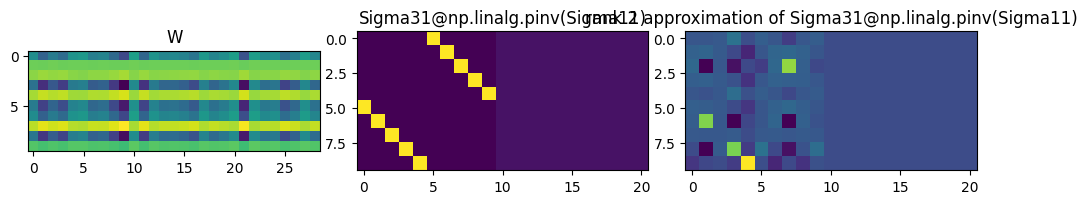

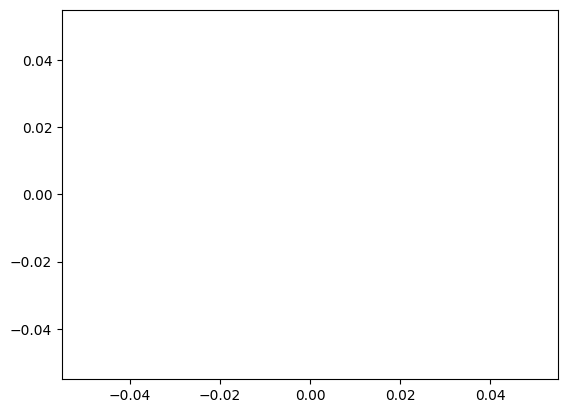

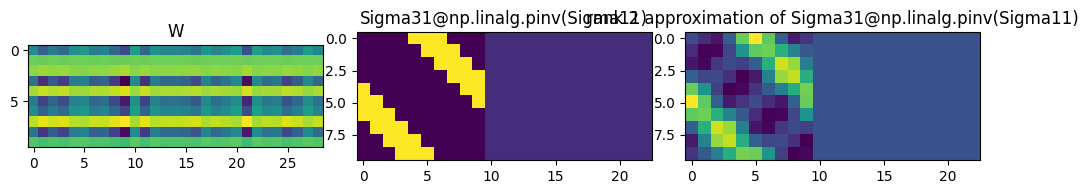

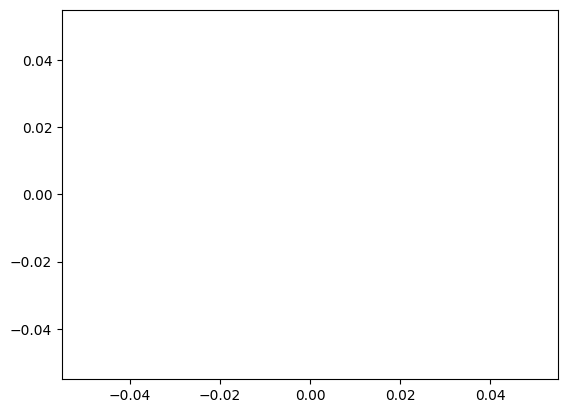

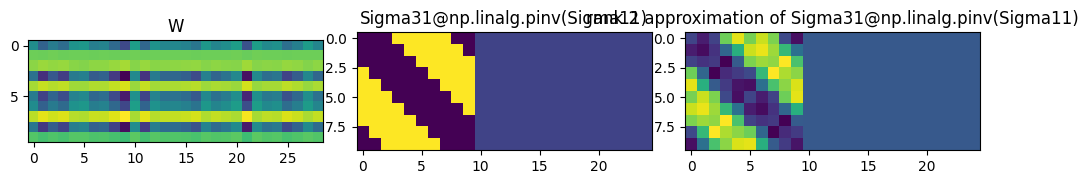

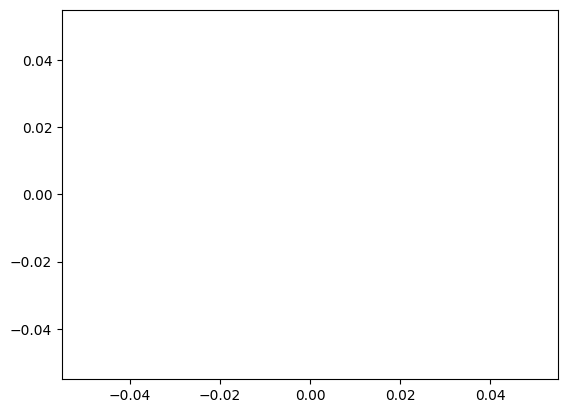

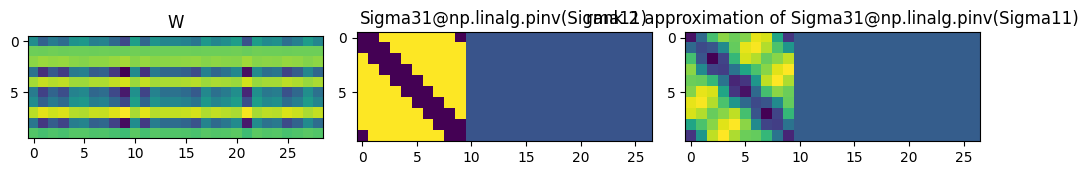

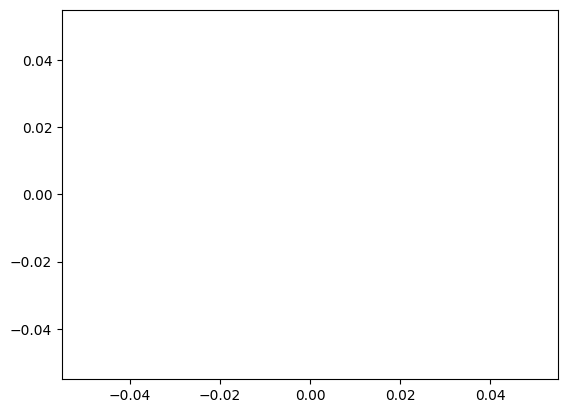

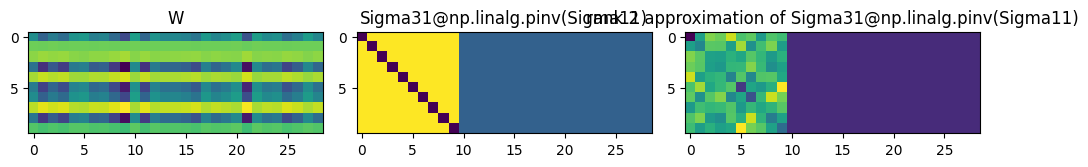

In [ ]:
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    Sigma11 = X.T@X
    Sigma31 = y.T@X
    US, SS, VS = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    sim_l = []
    for state_dict in data_dict['state_dict_l']:
        W = get_effective_W_from_model_dict(state_dict).cpu().numpy()
        UW, SW, VW = np.linalg.svd(W, full_matrices=False)
        sim_l.append(cosine_similarity(UW[:, 2], VS[2]))
    plt.plot(sim_l)
        # print(W.shape, (Sigma31@np.linalg.pinv(Sigma11)).shape)
        # print(UW.shape, VS.shape)
        # plt.imshow(abs(UW.T@VS.T))
        # plt.show()
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))
    ax1.imshow(W.T)
    ax1.set_title('W')
    ax2.imshow(Sigma31@np.linalg.pinv(Sigma11))
    ax2.set_title('Sigma31@np.linalg.pinv(Sigma11)')
    rank = 4
    ax3.imshow(US[:,:rank]@np.diag(SS[:rank])@VS[:rank,:])
    ax3.set_title('rank 2 approximation of Sigma31@np.linalg.pinv(Sigma11)')
    plt.tight_layout()
    plt.show()

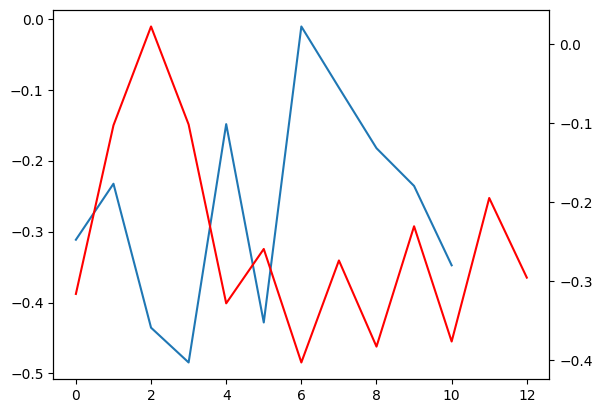

In [ ]:
W1 = get_effective_W_from_model_dict(data_dict_l[0]['final_weights']).cpu().numpy()
Win = data_dict_l[1]['final_weights']['input_layer.weight'].cpu().numpy().T
X = data_dict_l[1]['X'].cpu().numpy()
U, S, V = np.linalg.svd(W1)
U1, S1, V1 = np.linalg.svd(Win)
plt.plot(U[:,0])
plt.gca().twinx().plot(U1[:, 0], c='r')
plt.show()

/tmp/ipykernel_3166459/1416830102.py:31: RuntimeWarning: divide by zero encountered in log10
  loc_X_arr, action_taken_arr, bins=[x_edges, y_edges], weights=np.log10(var)
/tmp/ipykernel_3166459/1416830102.py:31: RuntimeWarning: invalid value encountered in log10
  loc_X_arr, action_taken_arr, bins=[x_edges, y_edges], weights=np.log10(var)


ValueError: All-NaN slice encountered

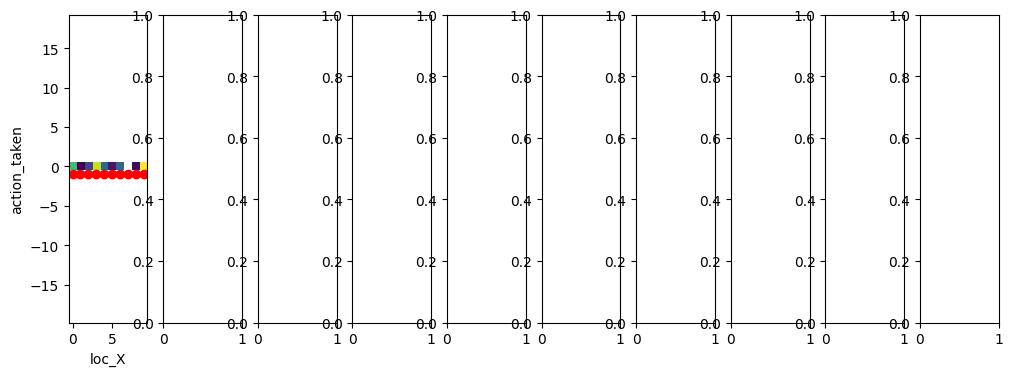

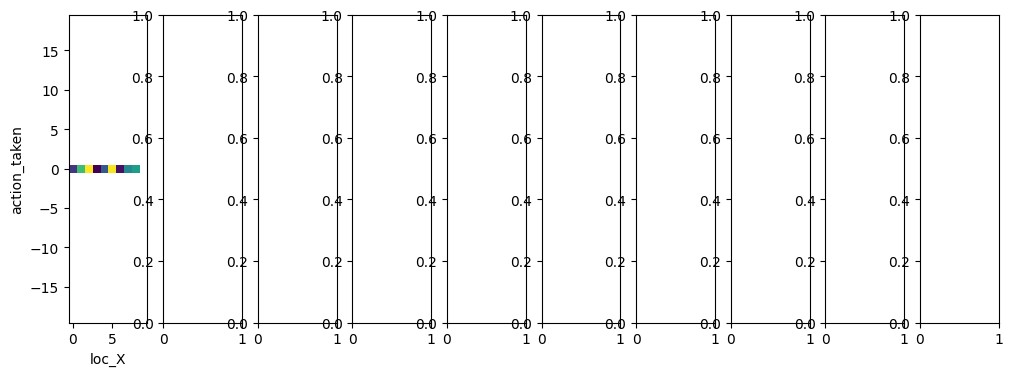

<Figure size 800x600 with 0 Axes>

In [ ]:
fig1, axs1 = plt.subplots(1, len(data_dict_l), figsize=(12, 4))
fig2, axs2 = plt.subplots(1, len(data_dict_l), figsize=(12, 4))
for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    action_taken = data_dict['action_taken']
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    cond = abs(action_taken) <= 1
    # X = X[cond]; y = y[cond]; action_taken = action_taken[cond]; loc_X = loc_X[cond]; loc_y = loc_y[cond]
    # W /= np.linalg.norm(W)
    scores = X@W
    losses = torch.nn.functional.cross_entropy(torch.from_numpy(scores), torch.from_numpy(y), reduction='none').numpy()
    true_scores = scores[np.arange(len(scores)), y]
    scores[np.arange(len(scores)), y] = 0
    margins = (true_scores[:,None] - scores).max(1)
    # 2D histogram: y-axis is action_taken, x-axis is loc_X, values are margins
    plt.figure(figsize=(8, 6))
    # Ensure action_taken and loc_X are 1D arrays
    action_taken_arr = np.array(action_taken).flatten()
    loc_X_arr = np.array(loc_X).flatten()
    # Use np.histogram2d to bin the data, weighting by margins
    bins_x = np.unique(loc_X_arr)
    bins_y = np.unique(action_taken_arr)
    # Add 1 to bins for histogram2d edges
    x_edges = np.arange(bins_x.min(), bins_x.max() + 2) - 0.5
    y_edges = np.arange(bins_y.min(), bins_y.max() + 2) - 0.5
    for var, name, axs in zip([losses, margins], ['losses', 'margins'], [axs1, axs2]):
        hist, xedges, yedges = np.histogram2d(
            loc_X_arr, action_taken_arr, bins=[x_edges, y_edges], weights=np.log10(var)
        )
        # Normalize by counts to get mean margin per bin
        counts, _, _ = np.histogram2d(
            loc_X_arr, action_taken_arr, bins=[x_edges, y_edges]
        )
        mean_margins = np.divide(hist, counts, out=np.zeros_like(hist), where=counts!=0)
        mean_margins[mean_margins==0] = np.nan
        # Plot with imshow (transpose for correct orientation)
        axs[i].imshow(
            mean_margins.T,
            aspect='auto',
            origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap='viridis'
        )   
        axs[i].axis('equal')
        axs[i].set_xlabel('loc_X')
        axs[i].set_ylabel('action_taken')
        axs[i].scatter(np.arange(mean_margins.shape[0]),np.nanargmin(mean_margins, 1)-1, c='red')
fig1.suptitle('losses')
fig2.suptitle('margins')

In [ ]:
mean_margins.argmin(1)

array([ 4, 26, 36,  7,  6,  0, 12,  1,  1, 14, 19, 35, 38, 32, 14, 33,  8,
        1,  0, 19])

/tmp/ipykernel_3166459/2542317781.py:19: UserWarning: Adding colorbar to a different Figure <Figure size 1600x400 with 21 Axes> than <Figure size 1600x400 with 20 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=axs[i], label='action_taken')
/tmp/ipykernel_3166459/2542317781.py:19: UserWarning: Adding colorbar to a different Figure <Figure size 1600x400 with 22 Axes> than <Figure size 1600x400 with 21 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=axs[i], label='action_taken')
/tmp/ipykernel_3166459/2542317781.py:19: UserWarning: Adding colorbar to a different Figure <Figure size 1600x400 with 23 Axes> than <Figure size 1600x400 with 22 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=axs[i], label='action_taken')
/tmp/ipykernel_3166459/2542317781.py:19: UserWarning: Adding colorbar to a different Figure <Figure size 1600x400 with 24 Axes> than <Figure size 1600x400 with 23 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=axs[i], label=

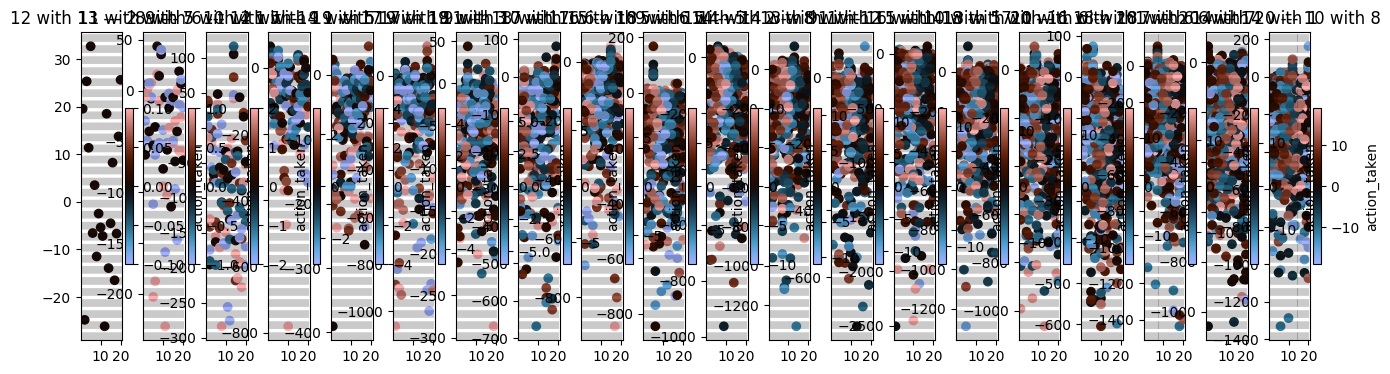

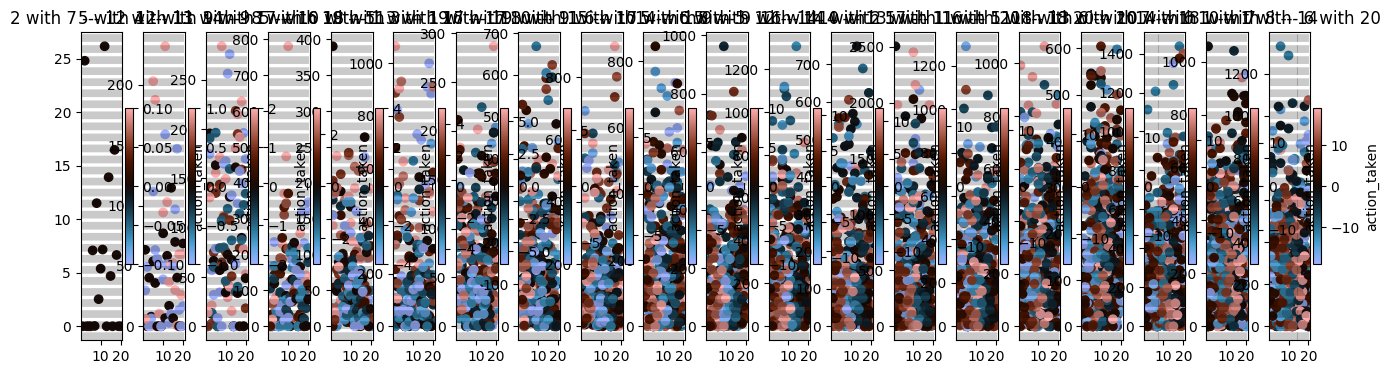

In [ ]:
fig, axs = plt.subplots(1, len(data_dict_l), figsize=(16, 4))
fig2, axs2 = plt.subplots(1, len(data_dict_l), figsize=(16, 4))
for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    action_taken = data_dict['action_taken']
    loc_X = data_dict['loc_X']+1
    loc_y = data_dict['loc_y']+1
    cond = abs(action_taken) <= 1
    # X = X[cond]; y = y[cond]; action_taken = action_taken[cond]; loc_X = loc_X[cond]; loc_y = loc_y[cond]
    # W /= np.linalg.norm(W)
    scores = X@W
    losses = torch.nn.functional.cross_entropy(torch.from_numpy(scores), torch.from_numpy(y), reduction='none').numpy()
    true_scores = scores[np.arange(len(scores)), y]
    scores[np.arange(len(scores)), y] = -np.inf
    margins = (true_scores[:,None] - scores).min(1)
    sc = axs[i].scatter(loc_y, margins, c=action_taken, cmap='berlin')
    plt.colorbar(sc, ax=axs[i], label='action_taken')
    [axs[i].axvline(x=x, color='black', ls='--', alpha=0.2) for x in np.unique(loc_X)]
    txt = ' --- '.join([f'{loc_y[i]} with {scores[i].argmax()+1}' for i in margins.argsort()[:2]])
    axs[i].set_title(txt)

    sc = axs2[i].scatter(loc_y, losses, c=action_taken, cmap='berlin')
    plt.colorbar(sc, ax=axs2[i], label='action_taken')
    [axs2[i].axvline(x=x, color='black', ls='--', alpha=0.2) for x in np.unique(loc_X)]
    txt = ' --- '.join([f'{loc_y[i]} with {scores[i].argmax()+1}' for i in losses.argsort()[-2:]])
    axs2[i].set_title(txt)


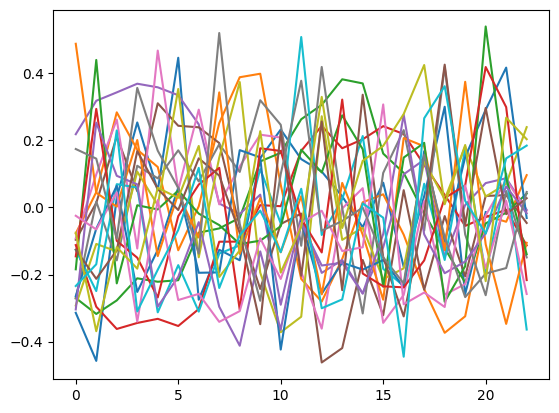

In [ ]:
loss_l = []
loss_rec_l = []
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()

    action_taken = data_dict['action_taken']
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    n_classes = len(np.unique(y))
    cond = abs(action_taken) <= 1
    bool_arr = np.concatenate([np.ones(n_classes, dtype=bool), abs(np.unique(action_taken))<=1])
    X = X[cond]; y = y[cond]; action_taken = action_taken[cond]; loc_X = loc_X[cond]; loc_y = loc_y[cond]
    X = X[:, bool_arr]
    W = W[bool_arr, :]
    W = W/np.linalg.norm(W)
    U, S, V = np.linalg.svd(W)
    rank = 10
    pca = X@U[:,:rank]@np.diag(S[:rank])@V[:rank,:]
    # plt.scatter(pca[:,0], pca[:,1], c=y)
    # plt.axis('equal')
    # plt.show()
    plt.plot(U[:,0])
#     loss_l.append(torch.nn.functional.cross_entropy(torch.from_numpy(pca), torch.from_numpy(y)))
#     loss_rec_l.append(torch.nn.functional.cross_entropy(torch.from_numpy(X@W), torch.from_numpy(y)))
# loss_l = np.array(loss_l)
# loss_rec_l = np.array(loss_rec_l)
# loss_l -= loss_l.min()
# loss_rec_l -= loss_rec_l.min()
# loss_l /= loss_l.max()
# loss_rec_l /= loss_rec_l.max()
# plt.plot(loss_l, label='pca')
# plt.plot(loss_rec_l, label='rec')
# plt.legend()
# plt.show()

Feasible point found.
No feasible point found.
infeasible


AttributeError: 'NoneType' object has no attribute 'T'

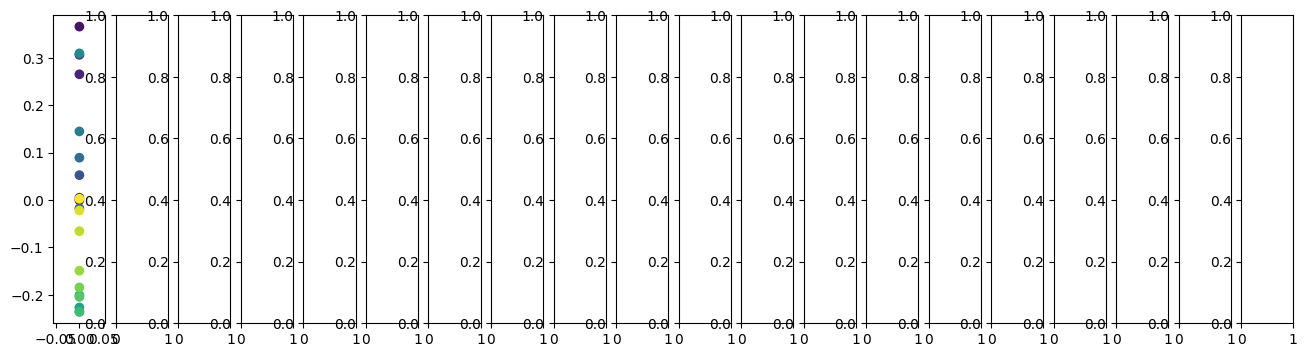

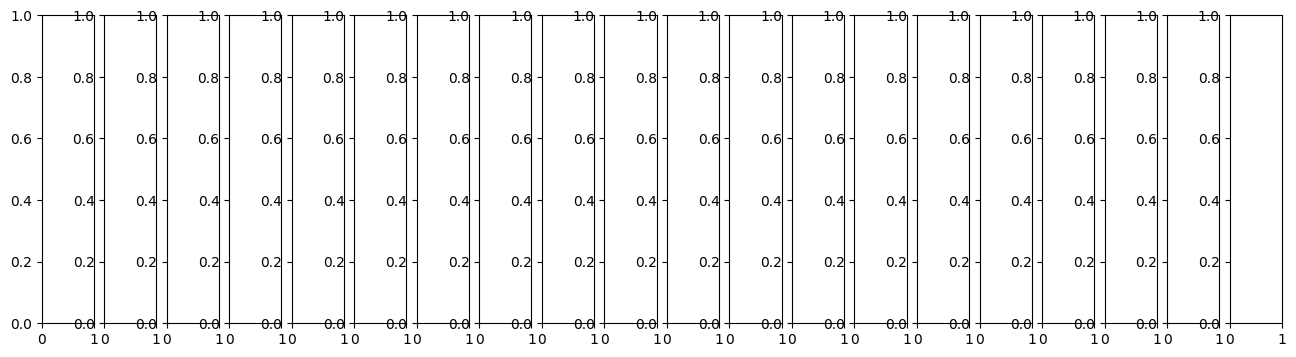

In [ ]:
import numpy as np
import cvxpy as cp
fig, axs = plt.subplots(1, len(data_dict_l), figsize=(16, 4))
fig2, axs2 = plt.subplots(1, len(data_dict_l), figsize=(16, 4))
W_LP_l = []
for j, d in enumerate(data_dict_l):
    action_taken = d['action_taken']
    X = d['X'].cpu().numpy()[abs(action_taken) <= 1]
    y = d['y'].cpu().numpy()[abs(action_taken) <= 1]
    loc_y = d['loc_y']
    loc_X = d['loc_X']
    action_taken = d['action_taken']
    labels = y.argmax(1)
    y = y.argmax(1)

    n_samples, n_features = X.shape
    n_classes = np.unique(labels).size

    # Define variables: weight vector for each class
    W_LP = cp.Variable((n_classes, n_features))

    # Constraints: for each sample i and each incorrect class k ≠ y_i,
    # enforce: (w_{y_i} - w_k) ⋅ x_i ≥ 1
    constraints = []
    for i in range(n_samples):
        xi = X[i]
        yi = labels[i]
        for k in range(n_classes):
            if k == yi:
                continue
            constraint = (W_LP[yi] - W_LP[k]) @ xi >= 1
            constraints.append(constraint)
    
    random_direction = np.random.randn(n_classes, n_features).T
    random_direction = random_direction / np.linalg.norm(random_direction)
    objective = cp.Maximize(0)

    prob = cp.Problem(objective, constraints)
    prob.solve()

    # Print results
    if prob.status == "optimal" or prob.status == "optimal_inaccurate":
        print("Feasible point found.")
    else:
        print("No feasible point found.")
        print(prob.status)
    W = W_LP.value.T
    # W /= np.linalg.norm(W)
    U, S, V = np.linalg.svd(W)
    rank = 2
    pca = X@U[:,:rank]@np.diag(S[:rank])@V[:rank,:]
    axs[j].scatter(pca[:,0], pca[:,1], c=labels)
    # axs[j].plot(W)
    axs[j].axis('equal')
    # Calculate minimal margins for each sample
    margins = []
    for i in range(n_samples):
        true_class = labels[i]
        x_i = X[i]
        # Compute margins to all other classes
        margins_i = []
        for k in range(n_classes):
            if k == true_class:
                continue
            margin = (W[:, true_class] - W[:, k]) @ x_i
            margins_i.append(margin)
        margins.append(min(margins_i))
    min_margin = np.min(margins)
    # axs[j].set_title(f'Min margin: {min_margin:.3f}, accuracy: {((X@W).argmax(1)==labels).mean():.3f}')
    
    # scores = X@W
    # losses = torch.nn.functional.cross_entropy(torch.from_numpy(scores), torch.from_numpy(y), reduction='none').numpy()
    # true_scores = scores[np.arange(len(scores)), y]
    # scores[np.arange(len(scores)), y] = -np.inf
    # margins = (true_scores[:,None] - scores).min(1)
    # sc = axs[j].scatter(loc_y, margins, c=action_taken, cmap='berlin')
    # plt.colorbar(sc, ax=axs[j], label='action_taken')
    # [axs[j].axvline(x=x, color='black', ls='--', alpha=0.2) for x in np.unique(loc_X)]
    # txt = ' --- '.join([f'{loc_y[i]} with {scores[i].argmax()+1}' for i in margins.argsort()[:2]])
    # axs[j].set_title(txt)

    # sc = axs2[j].scatter(loc_y, losses, c=action_taken, cmap='berlin')
    # plt.colorbar(sc, ax=axs2[j], label='action_taken')
    # [axs2[j].axvline(x=x, color='black', ls='--', alpha=0.2) for x in np.unique(loc_X)]
    # txt = ' --- '.join([f'{loc_y[i]} with {scores[i].argmax()+1}' for i in losses.argsort()[-2:]])
    # axs2[j].set_title(txt)


In [ ]:
plt.imshow(W)

In [ ]:
U, S, V = np.linalg.svd(W)
plt.plot(U[:,0])

In [ ]:
for data_dict in data_dict_l:
    # data_dict = data_dict_l[1]
    C = data_dict['C']
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights'])
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    W = W.cpu().numpy()
    if C.L == 0:
        U, S, V = np.linalg.svd(W, full_matrices=False)
        hidden = X @ U @ np.diag(S)
    else:   
        hidden = data_dict['hidden_states'][-1].cpu().detach().numpy()

    np.linalg.matrix_rank(W, tol=1)

    U, S, V = np.linalg.svd(W, full_matrices=False)
    # plt.plot(U[:,:4], marker='o')
    rank = 2
    accuracy = (((X@U[:,:rank])@np.diag(S[:rank])@V[:rank,:]).argmax(1)==y).mean()
    plt.plot(S, marker='o', label=f'rank {rank} accuracy: {accuracy:.2f}')
plt.legend()
plt.yscale('log')

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

for data_dict in data_dict_l:
    # data_dict = data_dict_l[1]
    C = data_dict['C']
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights'])
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    W = W.cpu().numpy()
    if C.L == 0:
        U, S, V = np.linalg.svd(W, full_matrices=False)
        hidden = X @ U @ np.diag(S)
    else:   
        hidden = data_dict['hidden_states'][-1].cpu().detach().numpy()

    np.linalg.matrix_rank(W, tol=1)

    U, S, V = np.linalg.svd(W, full_matrices=False)
    # plt.plot(U[:,:4], marker='o')
    rank = 3
    hidden = X@U[:,:rank]@np.diag(S[:rank])

    plt.scatter(hidden[:,0], hidden[:,1], c=y, cmap='viridis', marker='o')
    cmap = plt.get_cmap('viridis')
    for i in range(V.shape[0]):
        plt.arrow(0, 0, V[0, i]*100, V[1, i]*100, head_width=10, head_length=10, color=cmap(i/(V.shape[0]-1)))
    plt.axis('equal')
    plt.show()

In [ ]:
data_dict = data_dict_l[2]
C = data_dict['C']
X = data_dict['X'].cpu().numpy()
y = data_dict['y'].cpu().numpy().argmax(1)
W = get_effective_W_from_model_dict(data_dict['final_weights'])
loc_X = data_dict['loc_X']
loc_y = data_dict['loc_y']
W = W.cpu().numpy()
if C.L == 0:
    U, S, V = np.linalg.svd(W, full_matrices=False)
    hidden = X @ U @ np.diag(S)
else:   
    hidden = data_dict['hidden_states'][-1].cpu().detach().numpy()

np.linalg.matrix_rank(W, tol=1)

U, S, V = np.linalg.svd(W, full_matrices=False)
r = 1
W_rec = U[:,:r] @ np.diag(S[:r]) @ V[:r,:]
print(f'Accuracy: {((X@W_rec).argmax(1)==y).mean()}')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(W, marker='o')
ax1.set_title(data_dict['C'].max_move)
ax2.plot(S, marker='o')
plt.show()

plt.plot(data_dict['loc_X'], X[:,:C.length_corridors[0]]@U[:C.length_corridors[0],0]*S[0], marker='o', alpha=0.5)
plt.scatter(data_dict['loc_y'], X@U[:,0]*S[0], marker='o', c='tab:orange')
plt.show()


plt.scatter(X@U[:,0]*S[0], PCA(n_components=1).fit_transform(hidden), marker='o', c=data_dict['loc_y'])
# plt.axis('equal')

In [ ]:
U[:3,:3]

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex='col')
for i, data_dict in enumerate([data_dict_l[0], data_dict_l[1]]):
    C = data_dict['C']
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights'])
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    action_taken = data_dict['action_taken']
    W = W.cpu().numpy()
    U, S, V = np.linalg.svd(W, full_matrices=False)
    # plt.plot(U[:,0])
    W /= np.linalg.norm(W)
    X_filtered = X[abs(action_taken)==0]
    y_filtered = y[abs(action_taken)==0]
    scores = X_filtered@W
    true_scores = scores[np.arange(len(scores)), y_filtered]
    scores[np.arange(len(scores)), y_filtered] = 0
    margins = (true_scores[:,None] - scores).max(1)
    axs[i,0].hist(margins)
    # axs[i,0].set_ylim(0,1)
    axs[i,1].plot((X_filtered@W).T)
    axs[i,2].plot(W)
plt.show()

In [ ]:
d1 = data_dict_l[0]
d2 = data_dict_l[2]
W1 = get_effective_W_from_model_dict(d1['final_weights']).cpu().numpy()
W2 = get_effective_W_from_model_dict(d2['final_weights']).cpu().numpy()
X1 = data_dict_l[0]['X'].cpu().numpy()
y1 = data_dict_l[0]['y'].cpu().numpy().argmax(1)
X2 = data_dict_l[2]['X'].cpu().numpy()
y2 = data_dict_l[2]['y'].cpu().numpy().argmax(1)
loss1 = torch.nn.functional.cross_entropy(torch.tensor(X1@W1, dtype=torch.float64), torch.tensor(y1), reduction='none')
loss2 = torch.nn.functional.cross_entropy(torch.tensor(X2@W2, dtype=torch.float64), torch.tensor(y2), reduction='none')
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)
ax1.scatter(loss1, d1['loc_y'], c=d1['action_taken'])
ax1.set_xscale('log')
ax2.scatter(loss2, d2['loc_y'], c=d2['action_taken'])
ax2.set_xscale('log')
plt.show()

In [ ]:
data_dict = data_dict_l[0]

label = data_dict['y'].argmax(1).cpu().numpy()
loc_X = data_dict['loc_X']
action_taken = data_dict['action_taken']

action_hist = []
actions = np.unique(action_taken)
for action in actions:
    action_hist.append(np.histogram(label[action_taken==action], bins=np.arange(max(label)+2))[0])

position_hist = []
positions = np.unique(loc_X)
for position in positions:
    position_hist.append(np.histogram(label[loc_X==position], bins=np.arange(max(label)+2))[0])
action_hist = np.array(action_hist)
position_hist = np.array(position_hist)

i = 5
j = 2

plt.plot(position_hist[i], label=f'position {positions[i]}')
plt.plot(action_hist[j], label=f'action {actions[j]}')
plt.plot(position_hist[i] + action_hist[j], label=f'action {actions[j]} + position {positions[i]}')
plt.title(f'action {actions[j]} and position {positions[i]}')
plt.legend()
plt.show()

In [ ]:
yedges

In [ ]:
l=plt.plot((X@W).T)

In [ ]:
W /= np.linalg.norm(W)
scores = X@W
l=plt.plot((scores).T, marker='o')
plt.show()
true_scores = scores[np.arange(len(scores)), y]
scores[np.arange(len(scores)), y] = 0
margins = (true_scores[:,None] - scores).max(1)
plt.plot(margins)

In [ ]:
i = 10
plt.title(f'{loc_y[i]}')
plt.plot((X@U[:,[0]]@V[[0]])[i])

In [ ]:
fig = plt.figure(figsize=(len(data_dict_l)*3, 3))
axs = []
for i in range(len(data_dict_l)):
    ax = fig.add_subplot(1, len(data_dict_l), i+1)
    axs.append(ax)

for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    loc_y = data_dict['loc_y']
    from sklearn.svm import LinearSVC

    # Train a linear multiclass SVM
    svm = LinearSVC(C=1e6, multi_class='ovr', fit_intercept=False, max_iter=10000)
    svm.fit(X, y)

    # Compute functional margins for each sample
    W = svm.coef_.T  # shape (n_classes, n_features)
    U, S, V = np.linalg.svd(W, full_matrices=False)
    hidden = X@U@np.diag(S)
    acc = ((X@W).argmax(1)==y).mean()

    # Use 2D PCA
    hidden_pca = PCA(n_components=2).fit_transform(hidden)
    axs[i].scatter(hidden_pca[:,0], hidden_pca[:,1], c=loc_y, s=20)
    axs[i].set_xlabel('PC1')
    axs[i].set_ylabel('PC2')
    axs[i].set_title(f'N points: {X.shape[0]}, acc: {acc:.2f}')
    axs[i].axis('equal')
plt.tight_layout()
plt.show()

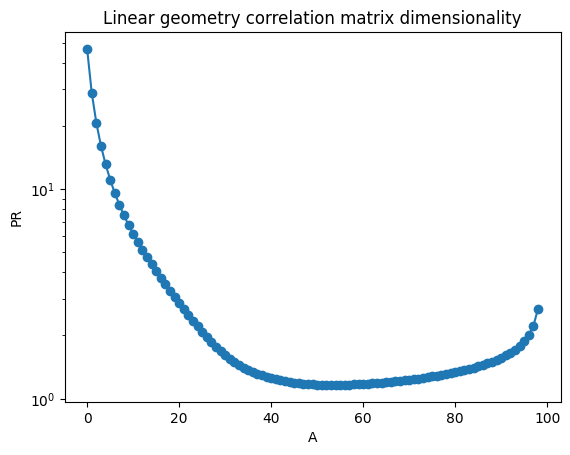

In [ ]:
PR_l = []
C.cyclic_corridors = False
C.print_progress = False
C.length_corridors[0] = 100
L = C.length_corridors[0]
for A in range(1,L):
    C.max_move = A
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)

    Sigma = np.linalg.pinv(X.T@X)@X.T@y
    PR_l.append(calc_PR(Sigma))
plt.plot(PR_l, marker='o')
plt.ylabel('PR')
plt.xlabel('A')
plt.yscale('log')
plt.title(f'Linear geometry correlation matrix dimensionality')
plt.show()
